# Canonical review — July 2026 desktop param lock + headwind add-back (2026-07-06)

Stakeholder-format review of the locked July desktop config:
- **Desktop (current):** re-anchored to fresh data (forecast_start **2026-07-06**), locked params
  **cps=0.08983, cpr=0.65, holiday_threshold=−0.032 (center)**, Win10 headwind softened +25k to
  **−1,345,000** at Dec-15. Overlays `l`+`o` applied; Iran fill in package.
- **Mobile (current):** settled this cycle (grad_moderate + marketing `m`), Win10 headwind −27,162.
- **Prior:** June 2026 *delivered* curve (June headwind −1,420,000 + the +500K desktop MozillaOnline
  step), which is what the published dashboard shows.

Plots saved to `data-official/2026-07/plots/canonical_review_2026-07-06/`. This is a REVIEW artifact,
not the final canonical rebuild (that bakes the locked desktop DAU into a fresh combined parquet once
approved).


In [1]:
# [rev-setup]
import os
import glob
import json
import sys
import time
import subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from google.cloud import bigquery

os.chdir(subprocess.run(["git", "rev-parse", "--show-toplevel"],
                        capture_output=True, text=True).stdout.strip())

# CURRENT (July) desktop = LOCKED param config (cps=0.08983, cpr=0.65, threshold=center),
# re-anchored to fresh data (forecast_start 2026-07-06). Win10 headwind now -1,345,000 (+25k add-back).
LOCKED_DESKTOP_PARQUET = glob.glob(
    "research/param-scans/results/desktop_gradient_round4/combo__cps08983_cpr65/"
    "*/mozaic_daily_forecast.2026-07-06.ld-D.adj-lo.parquet")[0]
# CURRENT (July) mobile = settled canonical mobile (grad_moderate + marketing m), from the combined
# parquet at 2026-06-29 (mobile was not re-anchored this cycle).
JULY_COMBINED = "data-official/2026-07/mozaic_daily_forecast.2026-06-29.gm+ld-D+NP.adj-lmo.parquet"
# PRIOR (June delivered).
PREV_DESKTOP = ("data-official/2026-06/desktop_cps0.15983_thresh050_recent13_clip0.6_cap426/"
                "mozaic_daily_forecast.2026-05-26.ld-D.raw.plus_iran.parquet")
PREV_MOBILE = ("data-official/2026-06/mobile_cps0.02_thresh32_recent13_clip0.6_cap426/"
               "mozaic_daily_forecast.2026-05-26.gm-D.adj-m.plus_iran.parquet")
JULY_ADJ_DIR = "data-official/2026-07/adjustments"   # headwind -1,345,000 desktop / -27,162 mobile
JUNE_ADJ_DIR = "data-official/2026-06/adjustments"   # June headwind -1,420,000
JUNE_MO_SPEC = "data-official/2026-06/mozillaonline/june_delivered_mo_tailwind.json"
PLOTS_DIR = "data-official/2026-07/plots/canonical_review_2026-07-06"
os.makedirs(PLOTS_DIR, exist_ok=True)

DISPLAY_START = pd.Timestamp("2026-01-01")
DISPLAY_END = pd.Timestamp("2026-12-31")
MEAS = pd.Timestamp("2026-12-15")
DESKTOP_FS = pd.Timestamp("2026-07-06")   # re-anchored
MOBILE_FS = pd.Timestamp("2026-06-29")    # settled
PREV_FS = pd.Timestamp("2026-05-26")
BQ_START = "2025-12-04"

DESKTOP_TARGET = 48_584_362               # param-search target (~+250k over June delivered)

# Rollup filters (data_source, segment, app_name)
DESK_KEY = ("legacy_desktop", '{"os": "ALL"}', "desktop")
MOB_KEY = ("glean_mobile", "{}", "ALL MOBILE")
print(f"locked desktop parquet: {LOCKED_DESKTOP_PARQUET}")


locked desktop parquet: research/param-scans/results/desktop_gradient_round4/combo__cps08983_cpr65/cps0.08983_thresh032_recent13_cpr0.65_ncp25_clip0.6/mozaic_daily_forecast.2026-07-06.ld-D.adj-lo.parquet


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.cloud.bigquery_storage_v1 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.bigquery_storage_v1 past that date.
  warnings.warn(message, FutureWarning)


In [2]:
# [rev-helpers]
sys.path.insert(0, "data-official/2026-06")
from export_canonical_curves import display_ma  # noqa: E402


def daily_to_28ma(dates, values):
    s = pd.Series(np.asarray(values, dtype=float), index=pd.to_datetime(np.asarray(dates)))
    return s.sort_index().rolling(28).mean()


def render_adjustment(spec, date_index):
    idx = pd.DatetimeIndex(date_index)
    out = {"desktop": pd.Series(0.0, index=idx), "mobile": pd.Series(0.0, index=idx)}
    if spec["type"] == "linear_ramp":
        start, anchor = pd.Timestamp(spec["start_date"]), pd.Timestamp(spec["anchor_date"])
        total = (anchor - start).days
        elapsed = np.maximum(0, (idx - start).days)
        out["desktop"][:] = spec.get("desktop_dau", 0) * elapsed / total
        out["mobile"][:] = spec.get("mobile_dau", 0) * elapsed / total
    elif spec["type"] == "step":
        start = pd.Timestamp(spec["start_date"])
        end = pd.Timestamp(spec["end_date"]) if "end_date" in spec else idx[-1]
        mask = (idx >= start) & (idx <= end)
        out["desktop"][mask] = spec.get("desktop_dau", 0)
        out["mobile"][mask] = spec.get("mobile_dau", 0)
    return out


def load_adjustments(adjustments_dir, date_index):
    idx = pd.DatetimeIndex(date_index)
    tot = {"desktop": pd.Series(0.0, index=idx), "mobile": pd.Series(0.0, index=idx)}
    for path in sorted(glob.glob(f"{adjustments_dir}/*.json")):
        r = render_adjustment(json.load(open(path)), idx)
        tot["desktop"] += r["desktop"]
        tot["mobile"] += r["mobile"]
    return tot


def apply_net_adjustment(ma, adjustments_dir, platform, forecast_start):
    net = load_adjustments(adjustments_dir, ma.index)[platform]
    out = ma.copy()
    fmask = out.index >= forecast_start
    out[fmask] = out[fmask] + net.reindex(out.index, fill_value=0.0)[fmask]
    return out


def june_mo_ma_tailwind(spec, date_index, platform):
    """June-delivered MozillaOnline +500K desktop step in 28d-MA space (28d rolling mean of the step)."""
    idx = pd.DatetimeIndex(date_index)
    amp = float(spec.get(f"{platform}_dau", 0))
    if amp == 0:
        return pd.Series(0.0, index=idx)
    start = pd.Timestamp(spec["start_date"])
    window = int(spec.get("ma_window", 28))
    step = pd.Series(np.where(idx >= start, amp, 0.0), index=idx).sort_index()
    return step.rolling(window, min_periods=window).mean().fillna(0.0)


def load_all_level_dau(path, key):
    data_source, segment, app = key
    df = pd.read_parquet(path)
    df["target_date"] = pd.to_datetime(df["target_date"])
    m = df[(df.country == "ALL") & (df.data_source == data_source)
           & (df.segment == segment) & (df.app_name == app)]
    return m.sort_values("target_date")[["target_date", "dau"]].reset_index(drop=True)


def curve_ma(path, key, forecast_start, adjustments_dir, platform, mo_spec_path=None):
    """Full display 28d-MA: seam-matched forecast MA + net headwind (+ optional June MO tailwind)."""
    d = load_all_level_dau(path, key)
    ma = apply_net_adjustment(display_ma(d["target_date"], d["dau"], forecast_start),
                              adjustments_dir, platform, forecast_start)
    if mo_spec_path:
        ma = ma + june_mo_ma_tailwind(json.load(open(mo_spec_path)), ma.index, platform)
    return ma


In [3]:
# [rev-actuals]
client = bigquery.Client(project="moz-fx-data-bq-data-science")
queries = {
    "desktop": f"""
        SELECT submission_date AS date, SUM(dau) AS dau
        FROM `moz-fx-data-shared-prod.telemetry.active_users_aggregates`
        WHERE app_name = "Firefox Desktop"
          AND submission_date BETWEEN '{BQ_START}' AND CURRENT_DATE("America/Los_Angeles") - 2
        GROUP BY submission_date ORDER BY 1
    """,
    "mobile": f"""
        SELECT submission_date AS date, SUM(dau) AS dau
        FROM `moz-fx-data-shared-prod.glean_telemetry.active_users_aggregates`
        WHERE app_name IN ("Fenix", "Firefox iOS", "Focus Android", "Focus iOS")
          AND submission_date BETWEEN '{BQ_START}' AND CURRENT_DATE("America/Los_Angeles") - 2
        GROUP BY submission_date ORDER BY 1
    """,
}
actual_ma = {}
t0 = time.time()
for i, (name, sql) in enumerate(queries.items(), 1):
    sys.stdout.write(f"[{i}/2] {name}...")
    sys.stdout.flush()
    df = client.query(sql).to_dataframe()
    df["date"] = pd.to_datetime(df["date"])
    actual_ma[name] = daily_to_28ma(df["date"], df["dau"])
    sys.stdout.write(f" {len(df)} rows ({time.time()-t0:.1f}s); latest {df['date'].max().date()}\n")
    sys.stdout.flush()


[1/2] desktop...

 214 rows (7.1s); latest 2026-07-05


[2/2] mobile...

 214 rows (11.8s); latest 2026-07-05


In [4]:
# [rev-compute]
# Current (July) curves.
desktop_cur = curve_ma(LOCKED_DESKTOP_PARQUET, DESK_KEY, DESKTOP_FS, JULY_ADJ_DIR, "desktop")
mobile_cur = curve_ma(JULY_COMBINED, MOB_KEY, MOBILE_FS, JULY_ADJ_DIR, "mobile")
# Prior (June delivered): June headwind, forecast start 2026-05-26, + June MO +500K step (desktop only).
desktop_prev = curve_ma(PREV_DESKTOP, DESK_KEY, PREV_FS, JUNE_ADJ_DIR, "desktop", mo_spec_path=JUNE_MO_SPEC)
mobile_prev = curve_ma(PREV_MOBILE, MOB_KEY, PREV_FS, JUNE_ADJ_DIR, "mobile")

d_cur, d_prev = desktop_cur.loc[MEAS], desktop_prev.loc[MEAS]
m_cur, m_prev = mobile_cur.loc[MEAS], mobile_prev.loc[MEAS]
print("=== Dec-15 2026 28d-MA (final KPI) ===")
print(f"DESKTOP  July(current) = {d_cur:,.0f}   June(prior) = {d_prev:,.0f}   "
      f"YoY-cycle Δ = {d_cur-d_prev:+,.0f}")
print(f"         param-search target = {DESKTOP_TARGET:,}   (current vs target {d_cur-DESKTOP_TARGET:+,.0f})")
print(f"MOBILE   July(current) = {m_cur:,.0f}   June(prior) = {m_prev:,.0f}   "
      f"cycle Δ = {m_cur-m_prev:+,.0f}")
print(f"ALL      July(current) = {d_cur+m_cur:,.0f}   June(prior) = {d_prev+m_prev:,.0f}")


=== Dec-15 2026 28d-MA (final KPI) ===
DESKTOP  July(current) = 48,585,483   June(prior) = 48,334,362   YoY-cycle Δ = +251,121
         param-search target = 48,584,362   (current vs target +1,121)
MOBILE   July(current) = 17,918,739   June(prior) = 17,511,100   cycle Δ = +407,639
ALL      July(current) = 66,504,222   June(prior) = 65,845,462


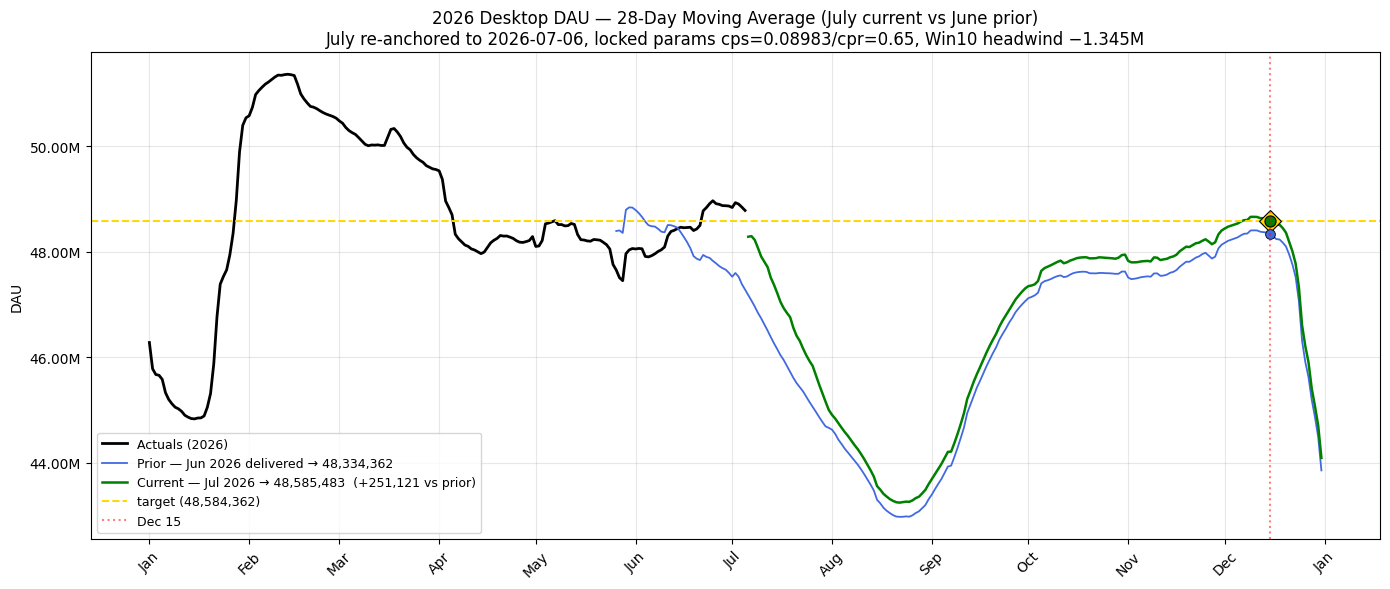

saved data-official/2026-07/plots/canonical_review_2026-07-06/desktop.png


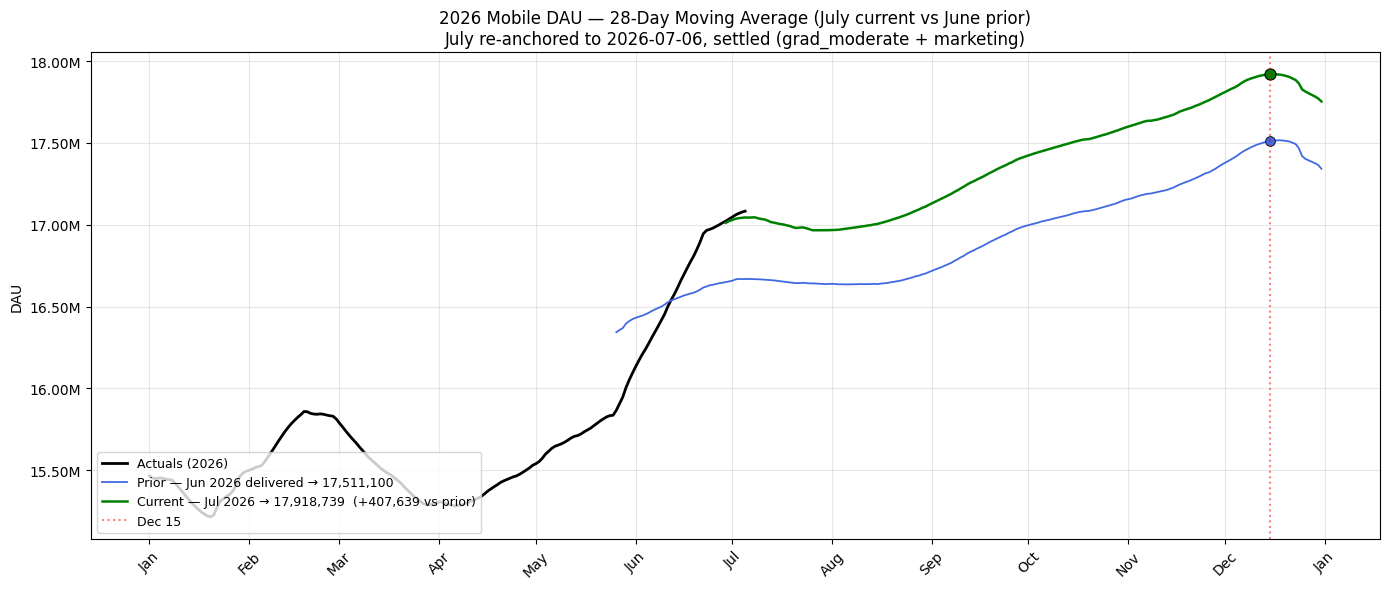

saved data-official/2026-07/plots/canonical_review_2026-07-06/mobile.png


In [5]:
# [rev-plots]
def clip_display(s):
    return s[(s.index >= DISPLAY_START) & (s.index <= DISPLAY_END)].dropna()


def clip_fc(s, fs):
    return s[(s.index >= fs) & (s.index <= DISPLAY_END)].dropna()


def mfmt(x, pos):
    return f"{x / 1e6:.2f}M"


def canonical_plot(platform, actual, cur, prev, cur_fs, prev_fs, cur_dec, prev_dec,
                   target=None, out=None):
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(clip_display(actual), color="black", lw=2, label="Actuals (2026)")
    ax.plot(clip_fc(prev, prev_fs), color="royalblue", lw=1.3,
            label=f"Prior — Jun 2026 delivered → {prev_dec:,.0f}")
    ax.plot(clip_fc(cur, cur_fs), color="green", lw=1.8,
            label=f"Current — Jul 2026 → {cur_dec:,.0f}  ({cur_dec-prev_dec:+,.0f} vs prior)")
    if target is not None:
        ax.axhline(target, color="gold", ls="--", lw=1.4, label=f"target ({target:,})")
        ax.plot(MEAS, target, marker="D", color="gold", ms=11, mec="black", mew=0.8, ls="None")
    ax.plot(MEAS, cur_dec, marker="o", color="green", ms=8, mec="black", mew=0.8, ls="None")
    ax.plot(MEAS, prev_dec, marker="o", color="royalblue", ms=7, mec="black", mew=0.6, ls="None")
    ax.axvline(MEAS, color="red", ls=":", alpha=0.5, label="Dec 15")
    ax.set_title(f"2026 {platform} DAU — 28-Day Moving Average (July current vs June prior)\n"
                 f"July re-anchored to 2026-07-06" +
                 (", locked params cps=0.08983/cpr=0.65, Win10 headwind −1.345M"
                  if platform == "Desktop" else ", settled (grad_moderate + marketing)"),
                 fontsize=12)
    ax.set_ylabel("DAU")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(mfmt))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    ax.legend(loc="lower left", fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    if out:
        plt.savefig(out, dpi=140, bbox_inches="tight")
    plt.show()
    if out:
        print(f"saved {out}")


canonical_plot("Desktop", actual_ma["desktop"], desktop_cur, desktop_prev, DESKTOP_FS, PREV_FS,
               d_cur, d_prev, target=DESKTOP_TARGET, out=f"{PLOTS_DIR}/desktop.png")
canonical_plot("Mobile", actual_ma["mobile"], mobile_cur, mobile_prev, MOBILE_FS, PREV_FS,
               m_cur, m_prev, target=None, out=f"{PLOTS_DIR}/mobile.png")
